<div style="border-left:4px solid #3D6FB0;padding:6px 0 8px 16px;"><div style="opacity:.72;font-size:12px;letter-spacing:1.4px;">Datos Masivos II · PRÁCTICA 2</div><div style="color:#3D6FB0;font-size:27px;font-weight:700;margin-top:4px;">Reglas de asociación en FIFA con PrefixSpan</div><div style="opacity:.72;font-size:14px;margin-top:6px;margin-bottom:10px;">Equipo Tres: Castrillo Cruz Karen Arlet, Ramos González Nadia, Zamora Antiga Ángel Javier.</div><img src="https://mmss.iimas.unam.mx/dmmss/wp-content/uploads/2026/02/cropped-LogoUNAM_IIMAS_Negro50-scaled-2.png" width="200"/></div>

## Instrucciones 
Utiliza el dataset asignado para identificar las reglas de asociación o patrones frecuentes, utilizando el algoritmo de preferencia. 

<div style="border-left:4px solid #524e64;padding:4px 0 6px 14px;margin:16px 0 6px 0;"><span style="color:#3D6FB0;font-size:21px;font-weight:700;">0. Contexto. Clickstream del mundial de Francia, 98</span></div>

Se trabajará con un conjunto de datos del mundial de la FIFA en Francia, año 1998, que retrata las sesiones de los visitantes al sitio web con las páginas iniciadas en orden. Las páginas se retratan como IDs anonimizados. 

Acorde al sitio de descarga ([SPMF - Public Datasets](https://www.philippe-fournier-viger.com/spmf/index.php?link=datasets.php)), se tiene la siguiente información:

| Métrica | Valor |
| :--- | :--- |
| Número de secuencias | 20,450 |
| Conteo de ítems | 2,990 |
| Longitud promedio por secuencia | 34.74 |

<div style="border-left:4px solid #524e64;padding:4px 0 6px 14px;margin:16px 0 6px 0;"><span style="color:#3D6FB0;font-size:21px;font-weight:700;">0.1 Los Datos </span></div>

El archivo a trabajar está disponible en formato de texto `.txt`. En cada secuencia, se usa `-1` para distinguir entre IDs de páginas, y `-2` para indicar el fin de una secuencia. 

<div style="border-left:4px solid #524e64;padding:4px 0 6px 14px;margin:16px 0 6px 0;"><span style="color:#3D6FB0;font-size:21px;font-weight:700;">0.2 Preparación de Entorno  </span></div>

In [50]:
# Manejo de datos
import numpy as np
import pandas as pd

# Visualización 
import matplotlib.pyplot as plt

# Extracción de características
from collections import Counter
from prefixspan import PrefixSpan

In [ ]:
secuencias = []
with open("data/FIFA.txt") as f:
    for linea in f:
        items = [int(x) for x in linea.split() if x not in ("-1", "-2")]
        if items:
            secuencias.append(items)

print(f'Cantidad de secuencias disponibles: {len(secuencias)}')

Cantidad de secuencias disponibles: 20450


<div style="border-left:4px solid #3D6FB0;padding:4px 0 6px 14px;margin:16px 0 6px 0;"><span style="color:#3D6FB0;font-size:21px;font-weight:700;">1. Selección de datos</span></div>

Definir la completitud de un conjunto de datos de esta naturaleza resulta especialmente complicado, dado que no conocemos las páginas originales a las cuales se refiere cada identificador. Adicionalmente, por naturaleza de las secuencias, el dataset cuenta con una gran cantidad de *valores nulos* (esto es, puede haber una secuencia de 2 y una de 100, y no necesariamente le faltan 98 datos a la más pequeña). Por ende, hacer una "selección" resulta complicado. Se trabajará con la información disponible en el documento en su totalidad.

<div style="border-left:4px solid #3D6FB0;padding:4px 0 6px 14px;margin:16px 0 6px 0;"><span style="color:#3D6FB0;font-size:21px;font-weight:700;">2. Análisis Exploratorio </span></div>

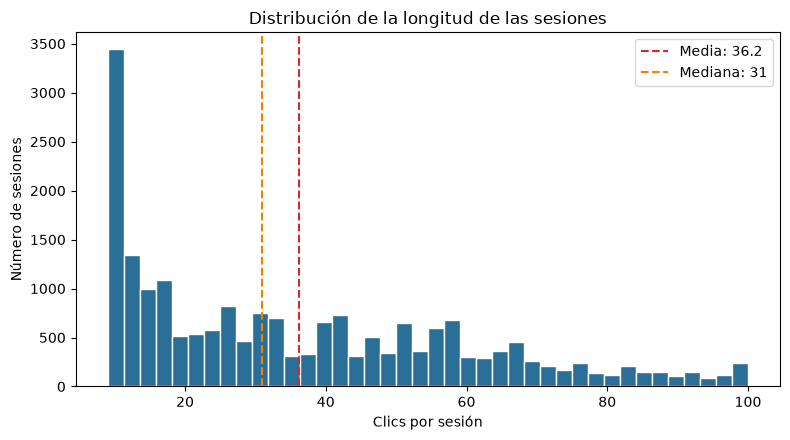

In [52]:
longitudes = np.array([len(s) for s in secuencias])
fig, ax = plt.subplots(figsize=(8, 4.5))
ax.hist(longitudes, bins=40, color="#2a6f97", edgecolor="white")
ax.axvline(longitudes.mean(), color="#d62828", ls="--", label=f"Media: {longitudes.mean():.1f}")
ax.axvline(np.median(longitudes), color="#f77f00", ls="--", label=f"Mediana: {np.median(longitudes):.0f}")
ax.set_xlabel("Clics por sesión")
ax.set_ylabel("Número de sesiones")
ax.set_title("Distribución de la longitud de las sesiones")
ax.legend()
fig.tight_layout()
plt.show()

Nótese que, en la preparación de entorno, corroboramos que el conjunto tiene el número de registros especificado en la documentación del dataset. Sin embargo, la media difiere por casi 1.5. Como era de esperarse, la distribución de longitud de sesiones está sesgada hacia la derecha, con una gran cantidad de sesiones con un par de páginas visitadas.

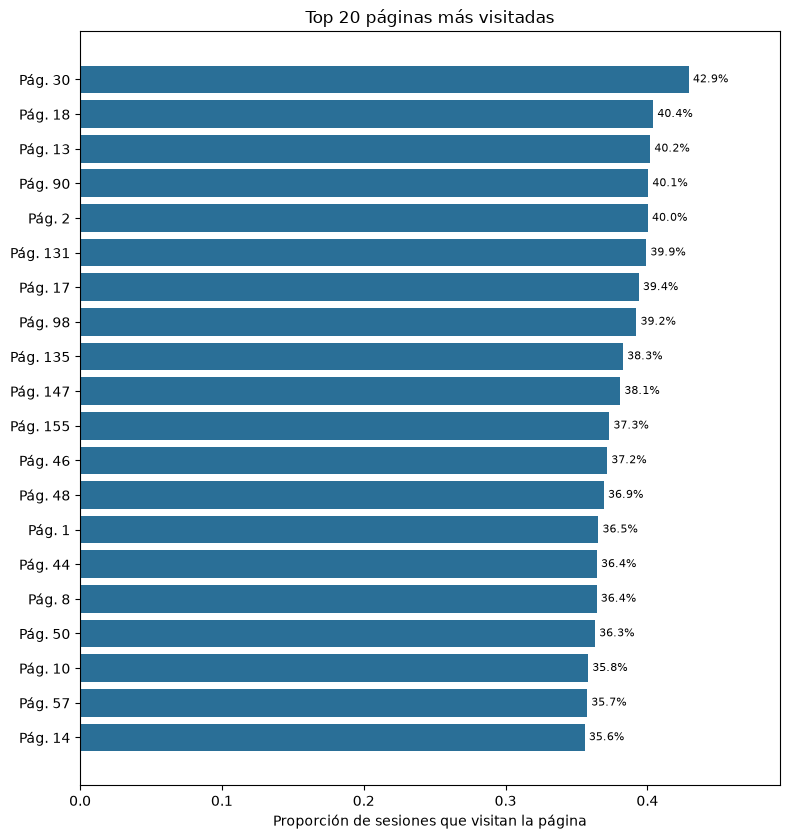

In [53]:
top_n = 20
n = len(secuencias)
conteo = Counter(p for s in secuencias for p in set(s))
top = conteo.most_common(top_n)[::-1]
etiquetas = [f"Pág. {p}" for p, _ in top]
proporciones = [c / n for _, c in top]

fig, ax = plt.subplots(figsize=(8, 0.35 * top_n + 1.5))
barras = ax.barh(etiquetas, proporciones, color="#2a6f97")
for barra, prop in zip(barras, proporciones):
    ax.text(prop + 0.003, barra.get_y() + barra.get_height() / 2, f"{prop:.1%}", va="center", fontsize=8)
ax.set_xlabel("Proporción de sesiones que visitan la página")
ax.set_title(f"Top {top_n} páginas más visitadas")
ax.set_xlim(0, max(proporciones) * 1.15)
fig.tight_layout()
plt.show()

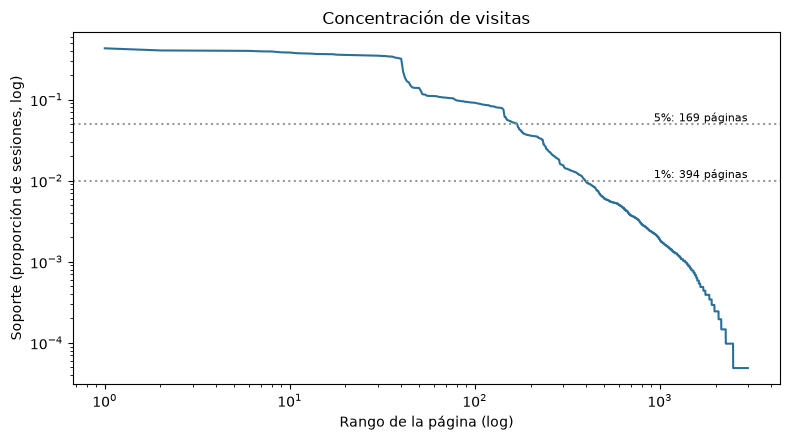

In [54]:
soportes = np.array(sorted(conteo.values(), reverse=True)) / n

fig, ax = plt.subplots(figsize=(8, 4.5))
ax.plot(np.arange(1, len(soportes) + 1), soportes, color="#2a6f97")
for umbral in (0.05, 0.01):
    k = int((soportes >= umbral).sum())
    ax.axhline(umbral, color="#999999", ls=":")
    ax.text(len(soportes), umbral, f" {umbral:.0%}: {k} páginas", va="bottom", ha="right", fontsize=8)
ax.set_xscale("log")
ax.set_yscale("log")
ax.set_xlabel("Rango de la página (log)")
ax.set_ylabel("Soporte (proporción de sesiones, log)")
ax.set_title("Concentración de visitas")
fig.tight_layout()
plt.show()

La caída abrupta indica que una pequeña cantidad de páginas está concentrando las visualizaciones totales (Posiblemente, páginas de inicio, menús o secciones principales), hasta llegar a páginas que tienen un número pequeño de visualizaciones. Solo 169 de las 2,990 páginas aparecen en al menos 5% de las sesiones, y solo 394 llegan al 1%.

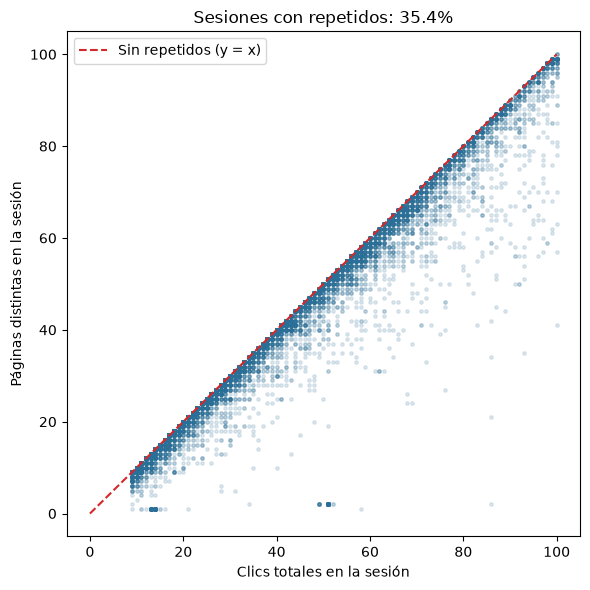

In [55]:
totales = np.array([len(s) for s in secuencias])
distintas = np.array([len(set(s)) for s in secuencias])
con_repetidos = (totales != distintas).mean()

fig, ax = plt.subplots(figsize=(6, 6))
ax.scatter(totales, distintas, s=6, alpha=0.15, color="#2a6f97")
maximo = totales.max()
ax.plot([0, maximo], [0, maximo], color="#d62828", ls="--",
        label="Sin repetidos (y = x)")
ax.set_xlabel("Clics totales en la sesión")
ax.set_ylabel("Páginas distintas en la sesión")
ax.set_title(f"Sesiones con repetidos: {con_repetidos:.1%}")
ax.legend()
fig.tight_layout()
plt.show()

Pese a que gran parte de las sesiones tiene un número reducido de páginas repetidas acorde al número de clics y su longitud, existe una gran cantidad de secuencias que sí tienen repeticiones. Esto puede deberse, por ejemplo, a la existencia de algún tipo de página principal, como se planteó un par de celdas atrás. 

<div style="border-left:4px solid #3D6FB0;padding:4px 0 6px 14px;margin:16px 0 6px 0;"><span style="color:#3D6FB0;font-size:21px;font-weight:700;">3. Transformación</span></div>

Dado que es relevante conservar el orden en el cual se visitan las páginas para identificar rutas frecuentes entre los clientes y así, por ejemplo, dar prioridad a las diversas páginas, se hará uso de `PrefixSpan`. El algoritmo PrefixSpan (minería de patrones secuenciales basada en proyecciones de prefijos) es un algoritmo muy conocido en el ámbito de la minería de datos secuenciales que extrae patrones secuenciales mediante el método de crecimiento de patrones. La idea básica de este método es que, en lugar de proyectar bases de datos de secuencias evaluando la frecuencia de aparición de subsecuencias, la proyección se realiza sobre prefijos frecuentes. Esto ayuda a reducir el tiempo de procesamiento, lo que en última instancia aumenta la eficiencia del algoritmo. Consideraremos un soporte mínimo de 20%, para brindar mayor flexibilidad y permitir la supervivencia de más patrones.

In [56]:
n = len(secuencias)
minsup = 0.2

ps = PrefixSpan(secuencias)
patrones = ps.frequent(int(minsup* n))
patrones_ordenados = sorted(patrones, reverse=True)

### Resultados de transformación

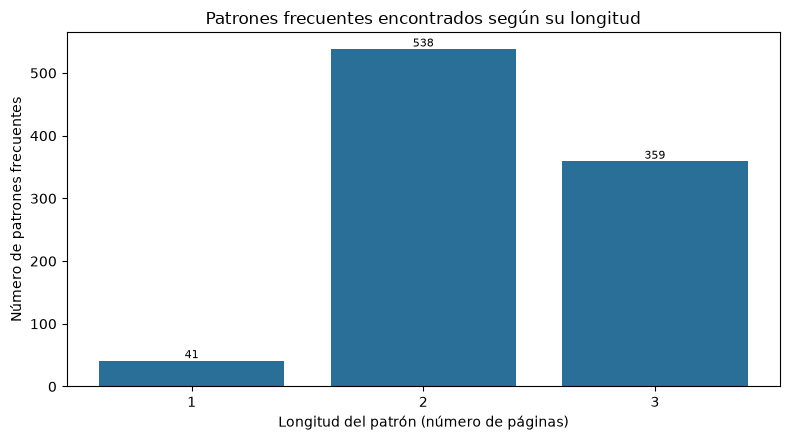

In [57]:
conteo = Counter(len(p) for _, p in patrones)
longitudes = sorted(conteo)
cantidades = [conteo[l] for l in longitudes]

fig, ax = plt.subplots(figsize=(8, 4.5))
barras = ax.bar([str(l) for l in longitudes], cantidades, color="#2a6f97")
ax.bar_label(barras, fontsize=8)
ax.set_xlabel("Longitud del patrón (número de páginas)")
ax.set_ylabel("Número de patrones frecuentes")
ax.set_title("Patrones frecuentes encontrados según su longitud")
fig.tight_layout()
plt.show()

La frecuencia máxima de patrones es 3. La mayor parte de los patrones constan de dos páginas. 

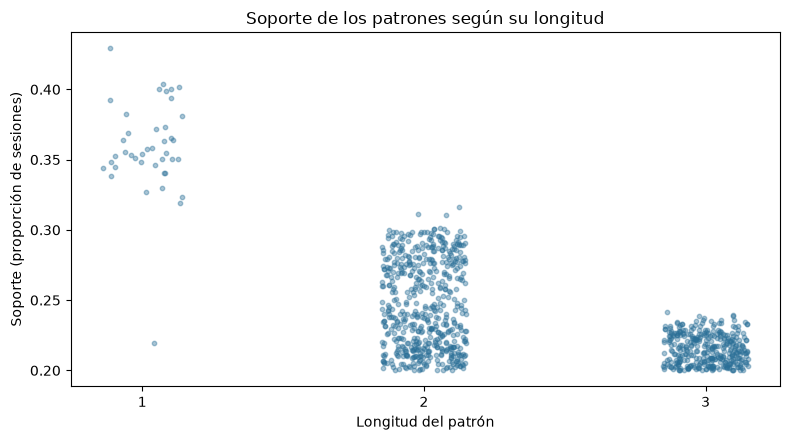

In [58]:
longitudes = np.array([len(p) for _, p in patrones])
soportes = np.array([s for s, _ in patrones]) / n
rng = np.random.default_rng(0)
jitter = rng.uniform(-0.15, 0.15, size=len(longitudes))

fig, ax = plt.subplots(figsize=(8, 4.5))
ax.scatter(longitudes + jitter, soportes, s=10, alpha=0.4, color="#2a6f97")
ax.set_xticks(sorted(set(longitudes.tolist())))
ax.set_xlabel("Longitud del patrón")
ax.set_ylabel("Soporte (proporción de sesiones)")
ax.set_title("Soporte de los patrones según su longitud")
fig.tight_layout()

Existe una relación lógica: A mayor longitud, más difícil es que aparezca en una gran cantidad de sesiones, teniendo un menor soporte. 

In [59]:
soporte = {tuple(p): s for s, p in patrones}
reglas = []
for s, p in patrones:
    if len(p) < 2:
        continue
    antecedente, consecuente = tuple(p[:-1]), p[-1]
    # Por anti-monotonía, ambos aparecen siempre en la salida de PrefixSpan
    conf = s / soporte[antecedente]
    lift = conf / (soporte[(consecuente,)] / n)
    reglas.append({"antecedente": list(antecedente), "consecuente": consecuente,
                    "soporte": s / n, "confianza": conf, "lift": lift})

display(pd.DataFrame(reglas))

,antecedente,consecuente,soporte,confianza,lift
0,[8],10,0.279315,0.767020,2.141666
1,[8],14,0.283814,0.779374,2.190818
2,[8],21,0.283521,0.778569,2.199134
3,[8],24,0.290024,0.796428,2.247406
4,[8],36,0.288362,0.791862,2.260096
...,...,...,...,...,...
892,[32],18,0.200098,0.611476,1.513336
893,[32],30,0.200489,0.612672,1.427659
894,[32],90,0.201369,0.615362,1.536338
895,[32],131,0.200636,0.613120,1.536181


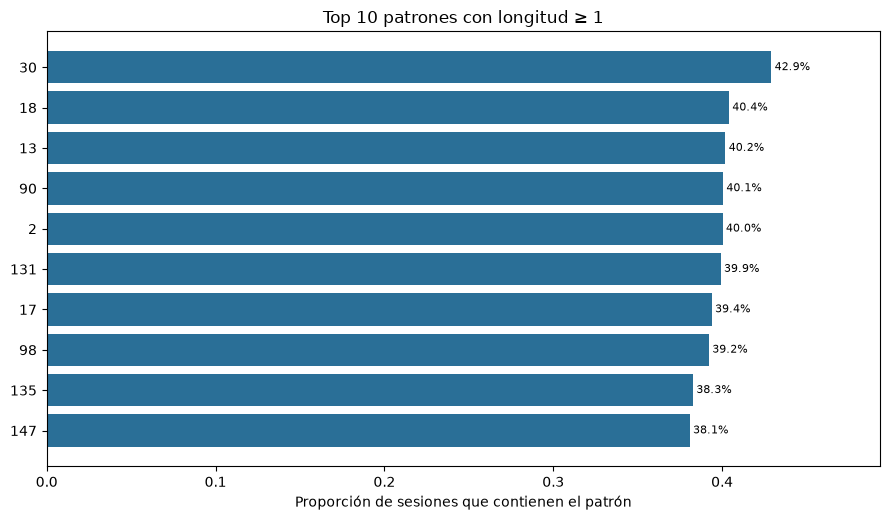

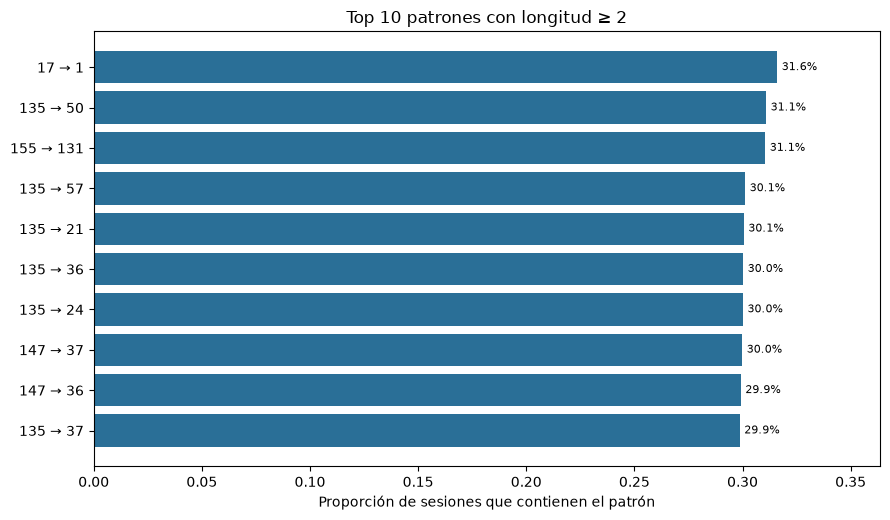

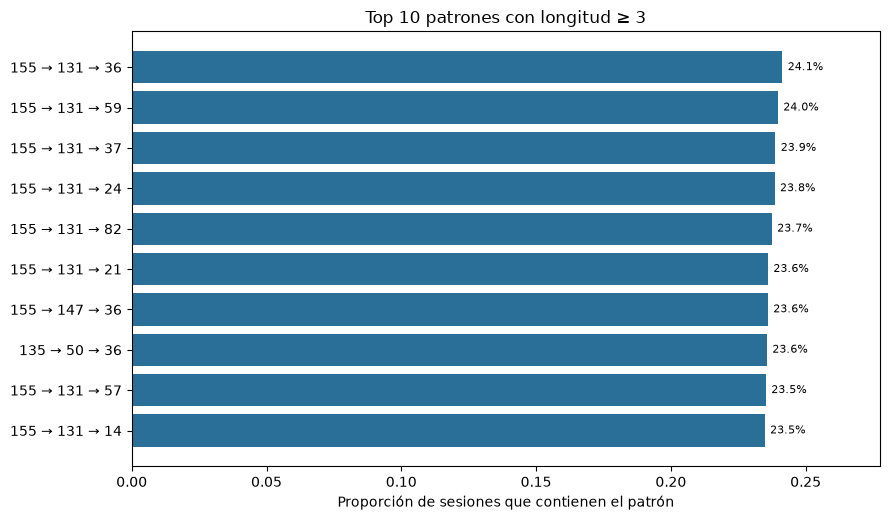

In [60]:
def grafica_top_patrones(patrones, n_sesiones, longitud_minima=2, top_n=10):
    """
    Barras horizontales con los patrones más frecuentes de al menos
    `longitud_minima` páginas, expresados como proporción de sesiones.
 
    inputs:
    -------
        patrones (list[tuple[int, list[int]]]): salida de PrefixSpan.frequent(),
        con tuplas (soporte, patrón).
        n_sesiones (int): número total de sesiones, para calcular proporciones.
        longitud_minima (int): longitud mínima del patrón a graficar.
        top_n (int): cantidad de patrones a mostrar.
 
    outputs:
    --------
        fig (matplotlib.figure.Figure): figura con los patrones más frecuentes,
        o una figura con un aviso si no hay patrones de esa longitud.
    """
    filtrados = sorted((p for p in patrones if len(p[1]) >= longitud_minima),
                       reverse=True)[:top_n]
    fig, ax = plt.subplots(figsize=(9, 0.38 * max(len(filtrados), 3) + 1.5))
 
    if not filtrados:
        ax.text(0.5, 0.5, f"No hay patrones de longitud ≥ {longitud_minima}\n"
                          "con el soporte mínimo elegido.",
                ha="center", va="center", transform=ax.transAxes)
        ax.axis("off")
        plt.show()
        return
 
    filtrados = filtrados[::-1]
    etiquetas = [" → ".join(str(x) for x in p) for _, p in filtrados]
    proporciones = [s / n_sesiones for s, _ in filtrados]
 
    barras = ax.barh(etiquetas, proporciones, color="#2a6f97")
    for barra, prop in zip(barras, proporciones):
        ax.text(prop + 0.002, barra.get_y() + barra.get_height() / 2,
                f"{prop:.1%}", va="center", fontsize=8)
    ax.set_xlabel("Proporción de sesiones que contienen el patrón")
    ax.set_title(f"Top {len(filtrados)} patrones con longitud ≥ {longitud_minima}")
    ax.set_xlim(0, max(proporciones) * 1.15)
    fig.tight_layout()
    plt.show()

for i in range(1, 4):
    grafica_top_patrones(patrones, n, longitud_minima=i)

Nótese que, no porque la página 30 sea la de mayor soporte individual, aparece en las secuencias más frecuentes de mayor longitud. 

<div style="border-left:4px solid #3D6FB0;padding:4px 0 6px 14px;margin:16px 0 6px 0;"><span style="color:#3D6FB0;font-size:21px;font-weight:700;">4. Conclusiones </span></div>

Para este tipo de conjuntos de datos, dado que cada sesión es una secuencia ordenada y no una canasta, PrefixSpan es el algoritmo natural, porque conserva el orden de las visitas, algo que apriori y FP-Growth descartan.

Es necesario mencionar que el soporte mínimo condiciona mucho el resultado. Con el soporte del 20% aparecen casi 900 patrones con secuencias de hasta tres páginas, pero el tiempo de cómputo se dispara a casi un minuto. Considerar un soporte más elevado reduciría significativamente el tiempo de cómputo, sin embargo, se debe tener en cuenta que esto reduciría la cantidad de asociaciones que se pueden detectar.

Con las reglas secuenciales el lift permite distinguir relaciones reales de simple popularidad. Con los soportes detectados, los lifts van de 1.5 a 2.1, aproximadamente. Esto quiere decir, por ejemplo, quien visita la página 8 tiene unas 2.1 veces más probabilidad de visitar después la 10 que una sesión cualquiera. Este lift es una aproximación, porque la tasa base considera apariciones de la página en cualquier momento de la sesión y no solo después del antecedente.

En resumen, el comportamiento de los usuarios gira en torno a un núcleo pequeño de páginas muy visitadas, y los patrones secuenciales frecuentes son cortos. Elegir el soporte mínimo implica un equilibrio entre la riqueza de los patrones y el costo computacional.